In [1]:

from pathlib import Path
import shutil


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from torchvision.datasets import ImageFolder
# V1 or V2? https://docs.pytorch.org/vision/main/transforms.html#v1-or-v2-which-one-should-i-use
import torchvision.transforms.v2 as T
import torch
from torch.utils.data import DataLoader, random_split
import torchmetrics

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

import kagglehub

# Download latest version
path = kagglehub.dataset_download("datamunge/sign-language-mnist")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/datamunge/sign-language-mnist


In [2]:

torch.manual_seed(12345)

train_df = pd.read_csv("/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv")
val_df = pd.read_csv("/kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv")

#train_class = train_df.pop(train_df.columns[0])
#train_img = train_df.iloc[:, 0:]
#print(train_img)
#print(train_class)

In [3]:
# Apply this during dataset loading
transform = T.Compose([
    T.ToDtype(torch.float32, scale=True),  # [0,1], done
])



In [4]:
#from claude.ai
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

class DigitDataset(Dataset):
    def __init__(self, df, transform=None):
        self.labels = torch.tensor(df.iloc[:, 0].values, dtype=torch.long)
        self.images = torch.tensor(df.iloc[:, 1:].values, dtype=torch.uint8)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx].reshape(1, 28, 28)
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [5]:
class_names = [chr(ord('A') + i) for i in range(26) if i != 9 and i != 25]
print(len(class_names), "classes")  # 24
print(class_names)
# ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']

24 classes
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


In [6]:
# Map original numeric labels → letter index
original_classes = sorted(train_df.iloc[:, 0].unique())
label_map = {orig: new for new, orig in enumerate(original_classes)}
print(label_map)
train_df.iloc[:, 0] = train_df.iloc[:, 0].map(label_map)
val_df.iloc[:, 0]   = val_df.iloc[:, 0].map(label_map)

{np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3, np.int64(4): 4, np.int64(5): 5, np.int64(6): 6, np.int64(7): 7, np.int64(8): 8, np.int64(10): 9, np.int64(11): 10, np.int64(12): 11, np.int64(13): 12, np.int64(14): 13, np.int64(15): 14, np.int64(16): 15, np.int64(17): 16, np.int64(18): 17, np.int64(19): 18, np.int64(20): 19, np.int64(21): 20, np.int64(22): 21, np.int64(23): 22, np.int64(24): 23}


In [7]:
SIZE = 28
BATCH = 16 # usually powers of 2 is a good idea, and no bigger than 32

train_set = DigitDataset(train_df, transform)
val_set = DigitDataset(val_df, transform)

train_T = T.Compose([
    T.ToImage(),
    # TODO: Any augmentation transforms you might want to include
    T.ToDtype(torch.float32, scale=True),
    T.Resize(SIZE),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    #T.Grayscale(num_output_channels=1)
    #T.ColorJitter()
    #T.RandomRotation((0, 45))
    #Added
    #T.AutoAugment()
])

train_val = ImageFolder("/kaggle/input/datasets/vincentha111/asl-dataset-alter/asl_dataset", train_T)
val_set, train_set = random_split(train_val, [0.2, 0.8])

#train_set += train_set2
#val_set += val_set2

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_set, batch_size=BATCH)


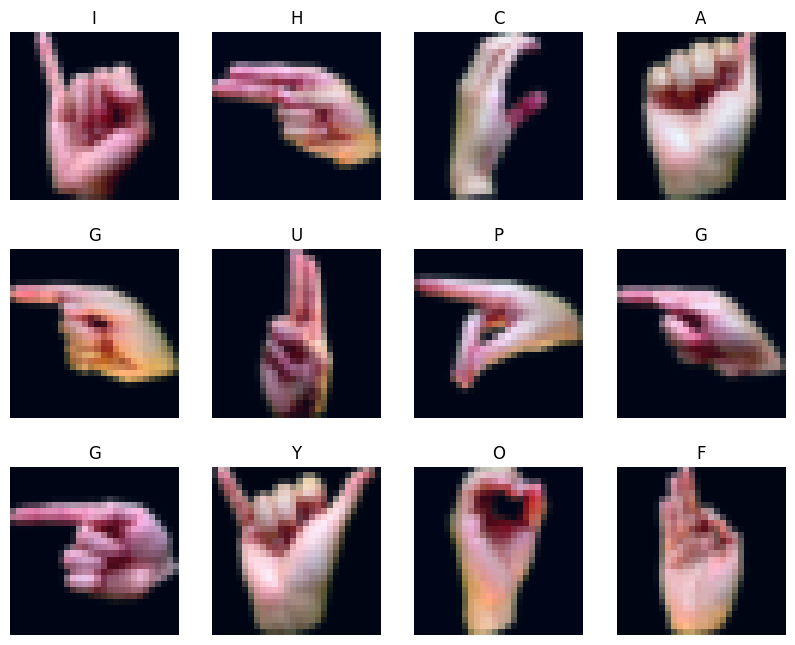

torch.Size([16, 3, 28, 28])


In [8]:

# take a look at a random sample
# note that calling next(iter(train_loader)) pulls 1 entire batch of images
images, labels = next(iter(train_loader))

# look at 12 images
fig, axes = plt.subplots(3, 4, figsize=(10,8))
for i, ax in enumerate(axes.flatten()):
    # Permute dimensions from (C, H, W) to (H, W, C) and convert to numpy
    im = images[i].permute(1, 2, 0).cpu().numpy()
    # scale back again because scaling is part of the pipeline
    im -= im.min()
    im /= im.max()
    ax.imshow(im)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
plt.show()

# what does that images tensor look like?
# [batch size, channels, rows, cols] (PyTorch format)
print(images.shape)

In [9]:


# build a simple CNN in PyTorch
# Yes, I usually like to have these imports at the top of the notebook, but this
# is the stuff you'll need to copy/paste into your production module.
import torch.nn as nn
import torch.nn.functional as F

class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            # First Conv block - 3 channels in (RGB), 32 out. Why? Dunno, seemed like somewhere to start.
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU()   ,
            # Why two conv blocks and then a pool?  again, just tried it and it worked.
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.LazyLinear(24) # 24 letters of the alphabet represented
            # Note: we don't need softmax here, CrossEntropyLoss handles it.
        )

    def forward(self, X):
        return self.network(X)


In [10]:

model = BasicCNN().to(device)

# Print the model summary
print(model)

BasicCNN(
  (network): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): LazyLinear(in_features=0, out_features=64, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): LazyLinear(in_features=0, out_features=24, bias=True)
  )
)


In [11]:
# blatantly copy pasted from https://github.com/ageron/handson-mlp/blob/main/12_deep_computer_vision_with_cnns.ipynb
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

def train(model, optimizer, loss_fn, metric, train_loader, valid_loader,
          n_epochs):
    history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}
    for epoch in range(n_epochs):
        total_loss = 0.0
        metric.reset()
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            total_loss += loss.item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            metric.update(y_pred, y_batch)
        history["train_losses"].append(total_loss / len(train_loader))
        history["train_metrics"].append(metric.compute().item())
        history["valid_metrics"].append(
            evaluate_tm(model, valid_loader, metric).item())
        print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    return history


     

In [12]:


n_epochs = 20
optimizer = torch.optim.AdamW(model.parameters())
xentropy = nn.CrossEntropyLoss()
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=24).to(device)
history = train(model, optimizer, xentropy, accuracy,
                train_loader, val_loader, n_epochs)


Epoch 1/20, train loss: 2.6783, train metric: 0.1843, valid metric: 0.7045
Epoch 2/20, train loss: 1.4656, train metric: 0.5104, valid metric: 0.8388
Epoch 3/20, train loss: 1.0495, train metric: 0.6410, valid metric: 0.9134
Epoch 4/20, train loss: 0.8634, train metric: 0.6769, valid metric: 0.9343
Epoch 5/20, train loss: 0.7220, train metric: 0.7306, valid metric: 0.9403
Epoch 6/20, train loss: 0.5640, train metric: 0.7754, valid metric: 0.9701
Epoch 7/20, train loss: 0.5892, train metric: 0.7754, valid metric: 0.9701
Epoch 8/20, train loss: 0.5752, train metric: 0.7836, valid metric: 0.9701
Epoch 9/20, train loss: 0.4813, train metric: 0.8164, valid metric: 0.9761
Epoch 10/20, train loss: 0.4789, train metric: 0.8179, valid metric: 0.9791
Epoch 11/20, train loss: 0.4335, train metric: 0.8433, valid metric: 0.9731
Epoch 12/20, train loss: 0.4303, train metric: 0.8358, valid metric: 0.9791
Epoch 13/20, train loss: 0.4576, train metric: 0.8246, valid metric: 0.9731
Epoch 14/20, train lo

inital results: (default CNN) no augmentation performed
Epoch 20/20, train loss: 0.0918, train metric: 0.9673, valid metric: 0.9244